<a href="https://colab.research.google.com/github/Mostafa-Seyedi/pytorch-fundamentals/blob/main/02_neural_network_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sklearn
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples, noise=0.03, random_state=42)

In [ ]:
len(X), len(y)

(1000, 1000)

In [ ]:
print(f"first 5 samples of X: \n {X[:5]}")
print("")
print(f"first 5 samples of y: \n {y[:5]}")

first 5 samples of X: 
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

first 5 samples of y: 
 [1 1 1 1 0]


In [ ]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:,1],
                        "label" : y })

circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


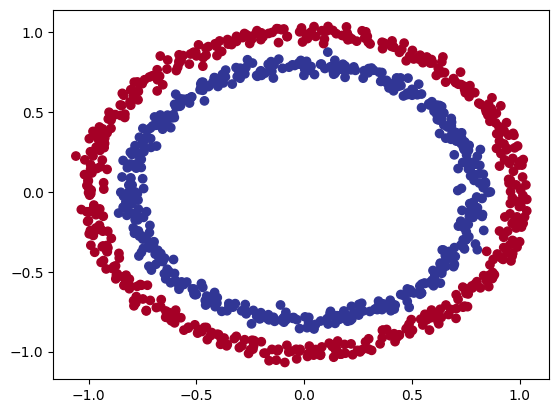

In [ ]:
# Visualizing
import matplotlib.pyplot as plt
plt.scatter(x = X[:,0],       # First index on x-axis
            y = X[:,1],       # Second index on y-axis
            c=y,              # Color them with labels
            cmap = plt.cm.RdYlBu);

### Binary classification

As we can see, this is a binary classification problem as we want to predict that is this going to be a blue dot or a red dot

### 1.1 Check input and output shapes

In [ ]:
X.shape, y.shape

((1000, 2), (1000,))

### 1.2 Turn data into tensors and create train and test splits

In [ ]:
import torch
torch.__version__

'2.10.0+cpu'

In [ ]:
type(X), X.dtype

(numpy.ndarray, dtype('float64'))

In [ ]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [ ]:
type(X), X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [ ]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
len(X_train), len(X_test)

(800, 200)

### 1.3 Building a model

In order to classify the blue and red dots, we need to build(or pick) a model

To do so, we want to:
1. Setup device agnostic code so our code will run on an accelerator (GPU if there is one)

2. Construct a model (by subclassing `nn.Module`)

3. Define a loss function and optimizer

4. Create a training and testing loop

In [ ]:
# Import PyTorch and nn
import torch
from torch import nn


# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

### Constructing a model

1. Subclasses `nn.Module` (almost all models in PyTorch subclass `nn.Module`)

2. Create 2 `nn.Linear()` layers that are capable of handling the shapes of our data

3. Defines a `forward()` method that outlines the forward pass (or forward computation) of the model

4. Instantiate an instance of our model class and send it to the target `device`

In [ ]:
# 1
class CircleModel(nn.Module):
  def __init__(self):
    super().__init__()
    # 2
    self.layer_1 = nn.Linear(in_features=2, out_features=5)  # take in 2 features and upscales them to 5 (it's an arbitrary choice) features
    # The higher the upscaling, the more chance for the network to learn
    self.layer_2 = nn.Linear(in_features=5, out_features=1)  # take in 5 features from previous layer and outputs a single feature (same shape as y)


  # 3
  def forward(self, x):
    return self.layer_2(self.layer_1(x))  #  "x" will go to layer_1 --> layer_1 output will go to layer_2 ---> final output


# 4
model = CircleModel().to(device)
model


CircleModel(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

### Using `nn.sequential` instead of `subclasses`

In [ ]:
# Let's replicate the above model using nn.sequential()
model = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

- As we can see, with `nn.sequential()` most of the codes will be implemented for us behind the sense

- The point is despote the fact that `nn.sequential()` is an esier way to create neural network, using subclasses gives us the benefit that when we have more complex operations and even more complex forward pass, it is important to know how to build our own subclasses of `nn.Module`

In [ ]:
model.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]])),
             ('0.bias', tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370])),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]])),
             ('1.bias', tensor([-0.1213]))])

In [ ]:
# Make predictions
with torch.inference_mode():
  untrained_preds = model(X_test.to(device))

print(f"Frist 10 predictions:\n{torch.round(untrained_preds[:10])}")
print(f"First 10 actual labels:\n{y_test[:10]}")

Frist 10 predictions:
tensor([[-0.],
        [-0.],
        [0.],
        [-0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [-0.]])
First 10 actual labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### 2.1 Setup loss function and optimizer

Which loss function or optimizer should we use?

- For example we regression we might want to use MSE or MAE

- For classification we might want binary cross entropy or categorical cross entropy

- As a reminder, loss function measures how **wrong** our models predictions are.

- And for optimizers, two of most common and useful are SGD and Adam, however PyTorch has many built-in options.

** For loss function, we're going to use `torch.nn.BECWithLogitsLoss()`

In [ ]:
# Setup the loss function
loss_fn = nn.BCEWithLogitsLoss() # built-in sigmoid activation function

# We could also use "nn.BCELoss()" which required inputs to have gone through the sigmoid activation function before inputting to BCELoss:
# nn.sequential(
#     nn.sigmoid(),
#     nn.BCELoss()
# )


# Setup optimizer
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

In [ ]:
# Calcuate accurary
def accurary_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc

### 3. Train a model
To train our model, we need to build a training loop with following steps:

1. Forward pass
2. Calcualte the loss
3. Optimizer zero grad
4. Loss backward (backpropagation)
5. Optimizer step (gradient descent)

### 3.1 Going from raw logits -(to)-> predictions probabilities -(to)-> predictions labels

- Our model outputs are going to be raw **logits**.

- We can convert these **logits** into **prediction probabilities** by passing them to some kind of activation function (e.g. sigmoid for binary cross entropy and softmax for multicalss classification)

- Then we can covert our model's prediction probabilities to **prediction labels** by either rounding them or taking the `argmax()`


In [ ]:
# First 5 outputs of the forward pass on the test data
# Idealy its better to put the model on eval mode for prediction and use inference_mode
model.eval()
with torch.inference_mode():
  y_logits = model(X_test.to(device))[:5]
y_logits

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]])

In [ ]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [ ]:
# Use the sigmoid activation function on our model logits to turn them into prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]])

For our prediction probabilities values, we need to perform a range-style rounding on them:

- `y_pred_probs` >= 0.5, `y = 1` (class 1)
- `y_pred_probs` < 0.5, `y = 0` (class 0)

In [ ]:
# Find the predicted labels
y_preds = torch.round(y_pred_probs)

# In full (logits --> pred probs --> pred labels)
y_preds_labels = torch.round(torch.sigmoid(model(X_test.to(device))[:5]))
y_preds_labels

tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.]], grad_fn=<RoundBackward0>)

In [ ]:
# Check for equality
print(torch.eq(y_preds_labels.squeeze(), y_preds.squeeze()))
print(torch.eq(y_preds_labels, y_preds).sum())

tensor([True, True, True, True, True])
tensor(5)


### 3.2 Building a training and testing loop

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
for epoch in range(epochs):
  ### Training
  model.train()
  # 1. Forward pass
  y_logits = model(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # Turn logits to pred probs --. to pred labels

  # 2. Calculate loss / accuracy (calculating accuracy is not mandatory)

  loss = loss_fn(y_logits, y_train) # nn.BECWithLogitsLoss expects raw logits as input
  acc = accurary_fn(y_true=y_train, y_pred=y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. back propagation
  loss.backward()

  # 5. Optimizer step (gradienct descent)
  optimizer.step()

  ### Testing
  model.eval()
  with torch.inference_mode():
    # 1. forward pass
    test_logits = model(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # 2. Calculate test loss/acc
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accurary_fn(y_true=y_test, y_pred=test_pred)

    # print out what's happening
    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69796 | Acc: 51.88% | Test Loss: 0.69440, Test Acc: 58.00%
Epoch: 10 | Loss: 0.69590 | Acc: 51.25% | Test Loss: 0.69305, Test Acc: 53.00%
Epoch: 20 | Loss: 0.69490 | Acc: 51.62% | Test Loss: 0.69254, Test Acc: 49.50%
Epoch: 30 | Loss: 0.69435 | Acc: 51.12% | Test Loss: 0.69236, Test Acc: 49.50%
Epoch: 40 | Loss: 0.69401 | Acc: 50.88% | Test Loss: 0.69232, Test Acc: 51.00%
Epoch: 50 | Loss: 0.69378 | Acc: 50.25% | Test Loss: 0.69234, Test Acc: 50.00%
Epoch: 60 | Loss: 0.69362 | Acc: 50.00% | Test Loss: 0.69239, Test Acc: 51.50%
Epoch: 70 | Loss: 0.69351 | Acc: 50.25% | Test Loss: 0.69246, Test Acc: 51.00%
Epoch: 80 | Loss: 0.69342 | Acc: 49.88% | Test Loss: 0.69254, Test Acc: 50.00%
Epoch: 90 | Loss: 0.69336 | Acc: 49.88% | Test Loss: 0.69262, Test Acc: 53.00%


### 4. Make predictions and evaluate the model

From the metrics it looks like our model is't learning anything...

So in inspect it let's make some predictions and visualize them

- To do so we're going to import a function called `plot_decision_boundary()`

In [ ]:
import requests
from pathlib import Path

# Download helper function from learn PyTorch repo
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")

else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_decision_boundary, plot_decision_boundary, plot_predictions

helper_functions.py already exists


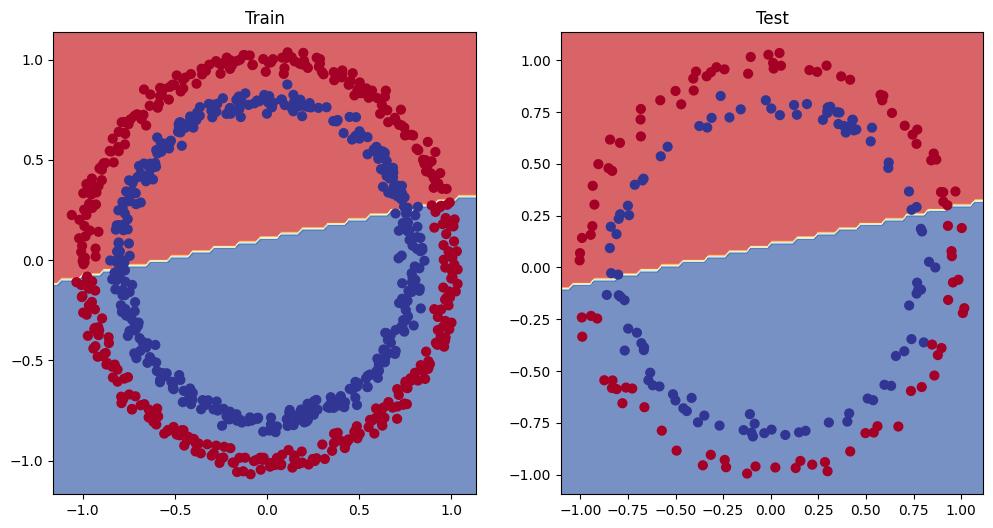

In [ ]:
# plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1) # row - column - index
plt.title("Train")
plot_decision_boundary(model,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model,X_test,y_test)

### Improving a model (from model prespective)

- Add more layers - give the model more chances to learn about patterns in the data

- Add more hidden units - go from 5 hidden units to 10 hidden units

- Fit for longer

- Changing the activaiton functions

- Change the learning rate

- Chnage the loss function

These options are all from a model's perspective because they deal directly with the model, rather than the data.



And beacause these options are all values we (as ML engineers and data scientists) can change, they are referred as **hyperparameters**



Lets try to improve our model by:
- Adding more hidden units: 5 -> 10
- Increase the number of layers: 2 -> 3
- Increase the number of epochs: 100 -> 1000

### Try to do these changes one by one to be able to track the results

In [ ]:
class CircleModel_v2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)


  def forward(self, x):
    return self.layer_3(self.layer_2(self.layer_1(x)))  #  "x" will go to layer_1 --> layer_1 output will go to layer_2 ---> final output


model_1 = CircleModel_v2().to(device)
model_1


CircleModel_v2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

In [ ]:
# Write a training and evaluation loop for model_1
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

# Put data on the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  ### Training
  model_1.train()

  # 1. Forward pass
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # 2. Calculate loss / acc
  loss = loss_fn(y_logits, y_train)
  acc = accurary_fn(y_true=y_train, y_pred=y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. back propagation
  loss.backward()

  # 5. Optimizer step (gradienct descent)
  optimizer.step()

  ### Testing
  model_1.eval()
  with torch.inference_mode():
    # 1. forward pass
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # 2. Calculate test loss/acc
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accurary_fn(y_true=y_test, y_pred=test_pred)

    # print out what's happening
    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69396 | Acc: 50.88% | Test Loss: 0.69261, Test Acc: 51.00%
Epoch: 100 | Loss: 0.69396 | Acc: 50.88% | Test Loss: 0.69261, Test Acc: 51.00%
Epoch: 200 | Loss: 0.69396 | Acc: 50.88% | Test Loss: 0.69261, Test Acc: 51.00%
Epoch: 300 | Loss: 0.69396 | Acc: 50.88% | Test Loss: 0.69261, Test Acc: 51.00%
Epoch: 400 | Loss: 0.69396 | Acc: 50.88% | Test Loss: 0.69261, Test Acc: 51.00%
Epoch: 500 | Loss: 0.69396 | Acc: 50.88% | Test Loss: 0.69261, Test Acc: 51.00%
Epoch: 600 | Loss: 0.69396 | Acc: 50.88% | Test Loss: 0.69261, Test Acc: 51.00%
Epoch: 700 | Loss: 0.69396 | Acc: 50.88% | Test Loss: 0.69261, Test Acc: 51.00%
Epoch: 800 | Loss: 0.69396 | Acc: 50.88% | Test Loss: 0.69261, Test Acc: 51.00%
Epoch: 900 | Loss: 0.69396 | Acc: 50.88% | Test Loss: 0.69261, Test Acc: 51.00%


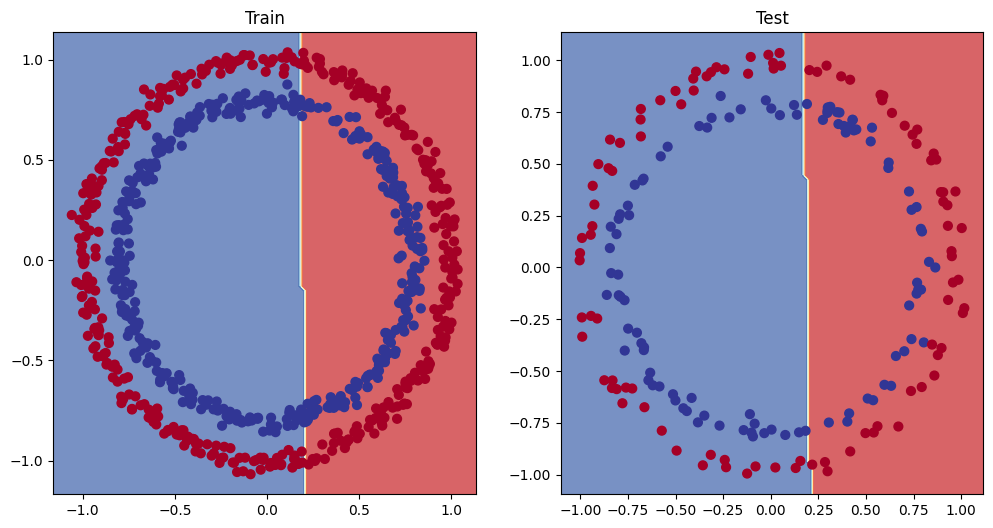

In [ ]:
# plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1) # row - column - index
plt.title("Train")
plot_decision_boundary(model_1,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1,X_test,y_test)

### 5.1 Preparing data to see if our model can fit a straight line

As we can see, the model we defined seems to learn nothing as its prediction is just like a random guess.

One way to troubleshoot to a larger problem is to test out a smaller problem


In [ ]:
# Create some data (same as previous one in notebook 01)

weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

X_regression = torch.arange(start, end, step).unsqueeze(dim=1)  # shape: [50, 1]
y_regression = weight * X_regression + bias   # y = 0.7x + 0.3

print(len(X_regression))
X_regression[:10], y_regression[:10]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400],
         [0.0500],
         [0.0600],
         [0.0700],
         [0.0800],
         [0.0900]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280],
         [0.3350],
         [0.3420],
         [0.3490],
         [0.3560],
         [0.3630]]))

In [ ]:
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]


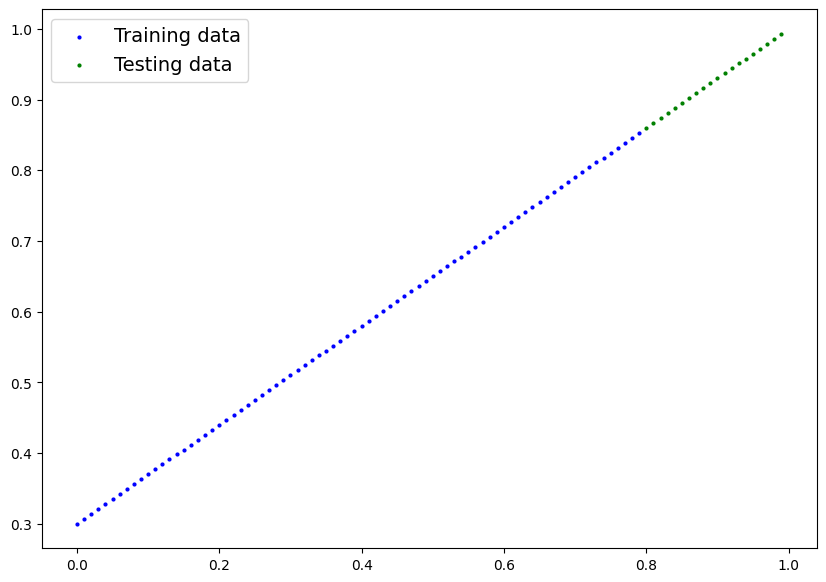

In [ ]:
plot_predictions(train_data=X_train_regression,train_labels=y_train_regression,
                 test_data=X_test_regression, test_labels=y_test_regression)

### Adjusting `model_1` to fit a straight line


In [ ]:
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Loss and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)

In [ ]:
# Train the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put the data on the target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

# Training
for epoch in range(epochs):
  y_pred = model_2(X_train_regression)
  loss = loss_fn(y_pred, y_train_regression)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Testing
  model_2.eval()
  with torch.inference_mode():
    test_pred = model_2(X_test_regression)
    test_loss = loss_fn(test_pred, y_test_regression)

# Print out what is happening
  if epoch % 100 == 0:
    print(f"Epoch {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")


Epoch 0 | Train Loss: 0.7599 | Test Loss: 0.9110
Epoch 100 | Train Loss: 0.0286 | Test Loss: 0.0008
Epoch 200 | Train Loss: 0.0253 | Test Loss: 0.0021
Epoch 300 | Train Loss: 0.0214 | Test Loss: 0.0031
Epoch 400 | Train Loss: 0.0196 | Test Loss: 0.0034
Epoch 500 | Train Loss: 0.0194 | Test Loss: 0.0039
Epoch 600 | Train Loss: 0.0190 | Test Loss: 0.0038
Epoch 700 | Train Loss: 0.0188 | Test Loss: 0.0038
Epoch 800 | Train Loss: 0.0184 | Test Loss: 0.0033
Epoch 900 | Train Loss: 0.0180 | Test Loss: 0.0036


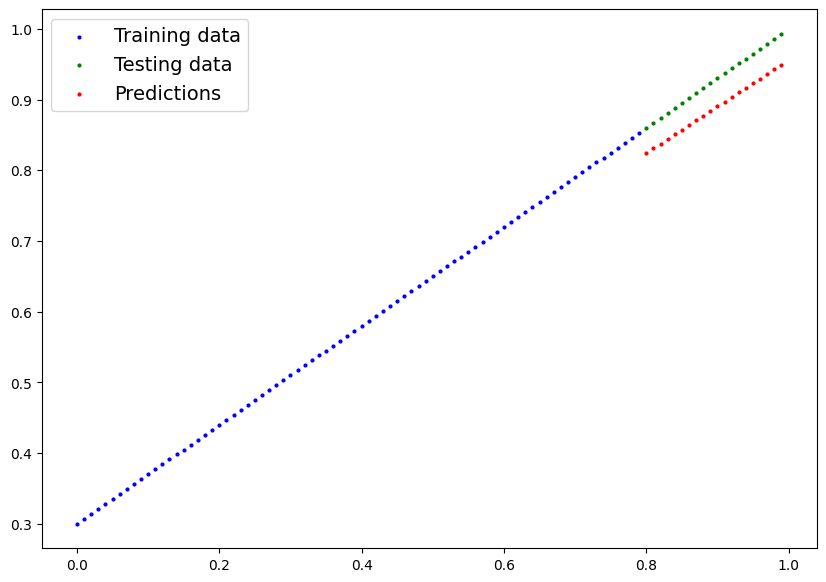

In [ ]:
# Turn on evaluation mode
model_2.eval()

# Make predictions (inference)
with torch.inference_mode():
  y_preds = model_2(X_test_regression)

# Plot data and predictions
plot_predictions(train_data=X_train_regression, train_labels=y_train_regression,
                test_data=X_test_regression, test_labels=y_test_regression,
                predictions=y_preds)

As we can see, the model we defined can learn but it works with linear data.

- So in order to model the dataset related to circles, we need to use `non-linearity`


### 6. The missing piece: `non-linearity`

**What patterns could we draw if we were given an infinite amount of a straight and non-straight lines?**

Or in ML terms, an infinite (but really its finite) of linear and non-linear functions?  

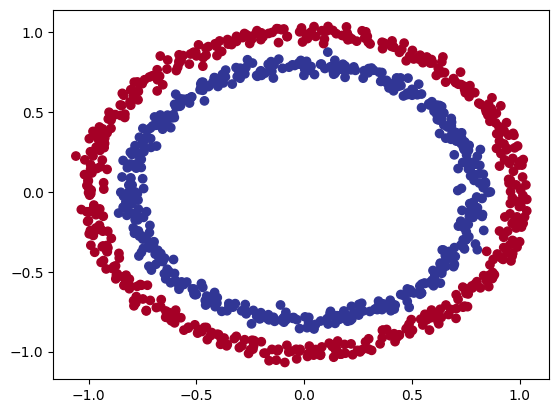

In [ ]:
# 6.1 Recreating non-linear data (red and blue circles)

n_samples = 1000

X, y = make_circles(n_samples,noise=0.03, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)


In [ ]:
# Convert data to tensors and then to train and test split

import torch
from sklearn.model_selection import train_test_split

# Turns data to tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 Building a model with non-linearity

Documentation: **https://docs.pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity**

Artificial nueral networks are a large combinations of linear (straight) and non-linear (non-straight) functions which are potentially able to find patterns in data.



In [ ]:
# Build a model with non_linear activation functions

from torch import nn
class CircleModel_v3(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU() # "non_linear activation function"

  def forward(self, x):
    # Where should we put our non_linear activation function?
    return self.layer_3(self.relu(self.layer_2(self.layer_1(x))))


model_3 = CircleModel_v3().to(device)

model_3

CircleModel_v3(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
# Setup the loss & optimizer function
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(), lr=0.1)

### 6.3 Training a model with non-linearity

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Set the number of epochs
epochs = 1000

# Build training and evaluation loop
for epoch in range(epochs):
  ### Training
  model_3.train()
  # 1. Forward pass
  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # Turn logits to pred probs --. to pred labels

  # 2. Calculate loss / accuracy (calculating accuracy is not mandatory)

  loss = loss_fn(y_logits, y_train) # nn.BECWithLogitsLoss expects raw logits as input
  acc = accurary_fn(y_true=y_train, y_pred=y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. back propagation
  loss.backward()

  # 5. Optimizer step (gradienct descent)
  optimizer.step()

  ### Testing
  model_3.eval()
  with torch.inference_mode():
    # 1. forward pass
    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # 2. Calculate test loss/acc
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accurary_fn(y_true=y_test, y_pred=test_pred)

    # print out what's happening
    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69833 | Acc: 50.00% | Test Loss: 0.69863, Test Acc: 49.00%
Epoch: 100 | Loss: 0.69289 | Acc: 50.88% | Test Loss: 0.69411, Test Acc: 47.00%
Epoch: 200 | Loss: 0.69015 | Acc: 53.37% | Test Loss: 0.69141, Test Acc: 50.00%
Epoch: 300 | Loss: 0.68762 | Acc: 56.62% | Test Loss: 0.68828, Test Acc: 55.00%
Epoch: 400 | Loss: 0.68469 | Acc: 60.00% | Test Loss: 0.68469, Test Acc: 61.00%
Epoch: 500 | Loss: 0.67985 | Acc: 56.00% | Test Loss: 0.67890, Test Acc: 60.50%
Epoch: 600 | Loss: 0.67280 | Acc: 56.00% | Test Loss: 0.67176, Test Acc: 60.50%
Epoch: 700 | Loss: 0.66304 | Acc: 64.50% | Test Loss: 0.66452, Test Acc: 65.00%
Epoch: 800 | Loss: 0.64710 | Acc: 74.12% | Test Loss: 0.65300, Test Acc: 71.50%
Epoch: 900 | Loss: 0.62182 | Acc: 81.62% | Test Loss: 0.63241, Test Acc: 78.00%


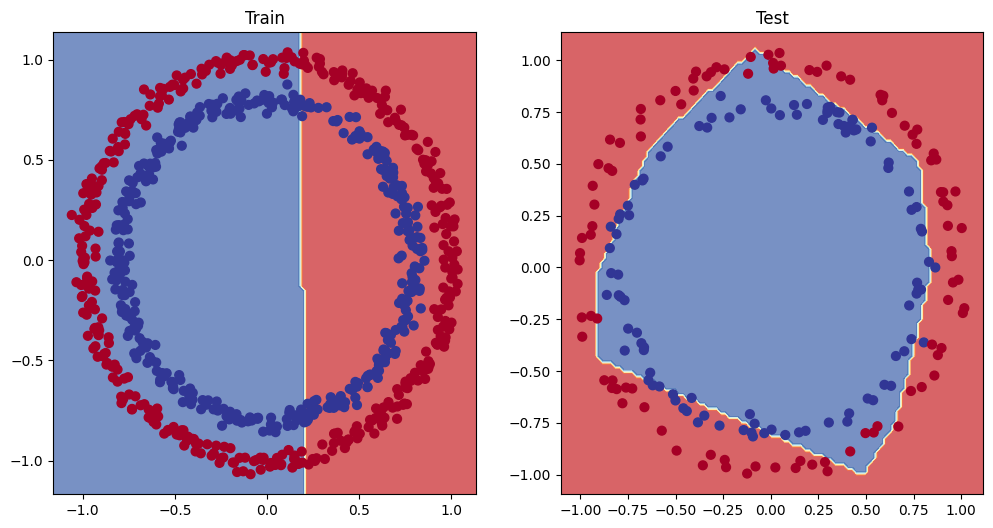

In [ ]:
# plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1) # row - column - index
plt.title("Train")
plot_decision_boundary(model_1,X_train,y_train)  # moddel_1 --> doesn't have non-linearity
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3,X_test,y_test)    # moddel_3 --> has non-linearity

### 7. Replicating non_linear activation functions

In nn, Instead of telling the model what to learn, we give it the tools to discover patterns in data and it tries to figure our the patterns by its own.


In [ ]:
# Create a tensor
A = torch.arange(-10, 10, 1, dtype=torch.float32)

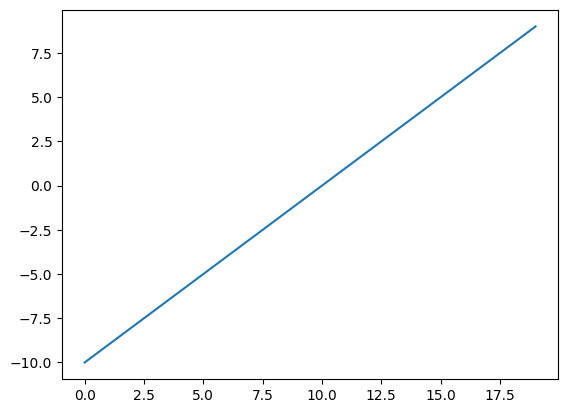

In [ ]:
# Visualize the tensor
plt.plot(A)

In [ ]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

In [ ]:
def relu(x: torch.Tensor) -> torch.Tensor:
  return torch.maximum(torch.zeros_like(x), x) # inputs must be tensors

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

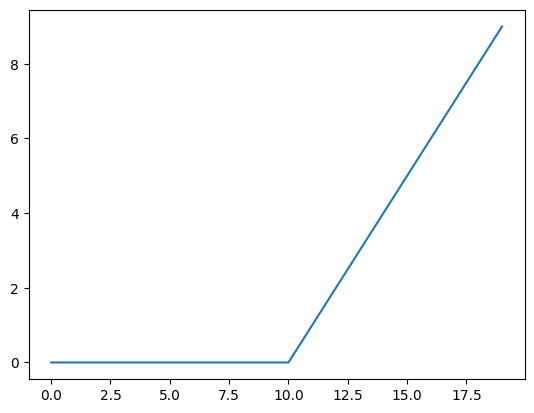

In [ ]:
plt.plot(torch.relu(A))

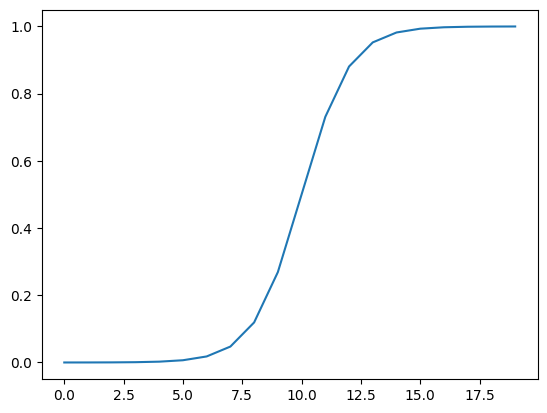

In [ ]:
# Let's do the same with sigmoid() activation function

def sigmoid(x):
  return 1 / (1 + torch.exp(-x))

plt.plot(sigmoid(A))

### 8. Putting all things together with a multi classification problem


#### 8.1 Creating a toy multi-class dataset


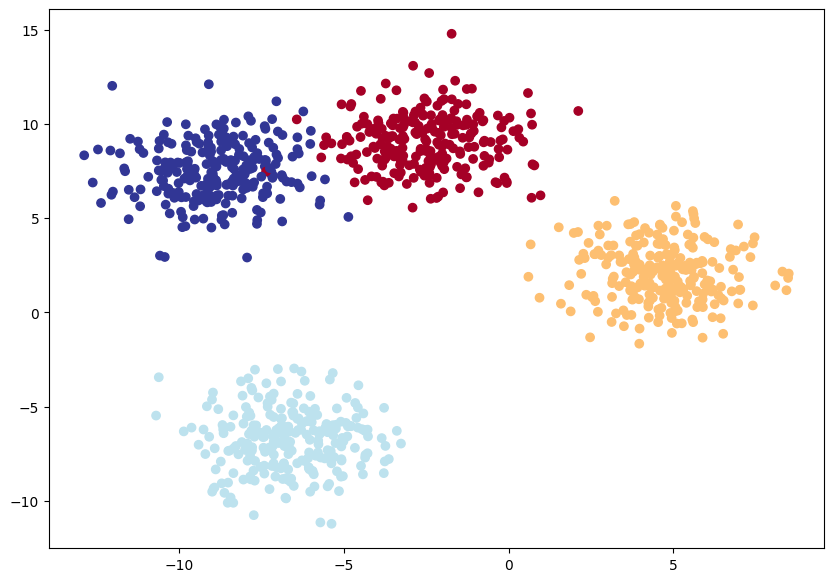

In [ ]:
# Import dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi_class data
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5, # give the clusters a little shake up
                            random_state=RANDOM_SEED)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)


# 3. Split into train and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, test_size=0.2, random_state=RANDOM_SEED)


# 4. plot data
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0], X_blob[:,1], c=y_blob, cmap=plt.cm.RdYlBu);







### 8.2 Building multi-class classification model in PyTorch


In [ ]:
# Create device agnostic code
device = "cude" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
# Build a multi-class classifcation
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features)
    )

  def forward(self,x):
    return self.linear_layer_stack(x)


# Create an instance of BlobModel and send it to the target device
model_4 = BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8).to(device)

model_4


BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

### 8.3.  Create a loss and optimizer function

In [ ]:
# Create a loss function for multi-class classification
loss_fn = nn.CrossEntropyLoss()

# Create an optimizer for multi-class classification - optimizer updates our model parameters to try and reduce the loss
optimizer = torch.optim.SGD(params=model_4.parameters(), lr=0.1)

### 8.4. Getting prediction probabilities for a multi-class PyTorch model

In order to evaluate and train and test our model, we need to convert our model's output (logtis) to prediction probabilities and then to prediction labels.

Logits (raw output of the model) --> pred probs (use `torch.softmax`) --> pred labels (take the `argmax` of the prediction probabilities)


In [ ]:
# Let's get some raw outputs of our model (logits)
model.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test.to(device))

y_logits[:10]

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834],
        [-0.1497, -1.0617, -0.7107, -0.1645],
        [ 0.1539, -0.2887,  0.1520, -0.0109],
        [-0.2154, -1.1795, -0.9300, -0.2745],
        [ 0.2443, -0.2472,  0.1649,  0.0061],
        [-0.2329, -1.2120, -0.9849, -0.3004]])

In [ ]:
# Convert our model's logits outputs to prediction probabilities (Using activation function)

y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
y_pred_probs[:5]

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834]])


tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463]])

In [ ]:
# Probability of softmax function (stochasticity)
# The 4 values are the probabilty like saying:       class_0 prob | class_1 prob | class_2 prob | class_3 prob
y_pred_probs[0], torch.sum(y_pred_probs[0])

(tensor([0.3169, 0.3244, 0.1405, 0.2182]), tensor(1.0000))

In [ ]:
# Now lets convert our model's predictions probabilities to prediction labels
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 1])

In [ ]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])

### 8.5. Creating the training and testing loop for multi-class PyTorch model

In [ ]:
# fit the multi-class model to the data
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
epochs = 100

# Put data to the target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

# Loop through data
for epoch in range(epochs):
  ### training
  model_4.train()
  y_logits = model_4(X_blob_train).to(device)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  loss = loss_fn(y_logits, y_blob_train)
  acc = accurary_fn(y_true=y_blob_train, y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  ### Testing
  model_4.eval()
  with torch.inference_mode():
    test_logits = model_4(X_blob_test).to(device)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)

    test_loss = loss_fn(test_logits, y_blob_test)
    test_acc = accurary_fn(y_true=y_blob_test, y_pred=test_pred)

  # Print what is happening
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 1.06362 | Acc: 54.62% | Test Loss: 1.00386, Test Acc: 55.00%
Epoch: 10 | Loss: 0.62096 | Acc: 97.25% | Test Loss: 0.63668, Test Acc: 98.00%
Epoch: 20 | Loss: 0.40612 | Acc: 98.75% | Test Loss: 0.41038, Test Acc: 100.00%
Epoch: 30 | Loss: 0.23616 | Acc: 99.12% | Test Loss: 0.22684, Test Acc: 99.50%
Epoch: 40 | Loss: 0.10442 | Acc: 99.25% | Test Loss: 0.09487, Test Acc: 99.50%
Epoch: 50 | Loss: 0.06402 | Acc: 99.25% | Test Loss: 0.05627, Test Acc: 99.50%
Epoch: 60 | Loss: 0.04968 | Acc: 99.25% | Test Loss: 0.04191, Test Acc: 99.50%
Epoch: 70 | Loss: 0.04243 | Acc: 99.25% | Test Loss: 0.03429, Test Acc: 99.50%
Epoch: 80 | Loss: 0.03799 | Acc: 99.25% | Test Loss: 0.02949, Test Acc: 99.50%
Epoch: 90 | Loss: 0.03501 | Acc: 99.25% | Test Loss: 0.02637, Test Acc: 99.50%


### 8.6. Making and evaluating predictions with a PyTorch multi-class model

In [ ]:
# Make predictions
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test).to(device)

# View the first 10 predictions
y_logits[:10]

tensor([[-0.6257,  6.0063, -7.6488, -8.4666],
        [-2.1813, -6.3889, -3.7303,  3.1376],
        [-3.4241, -3.9088,  3.1701, -2.6211],
        [-1.1539,  4.2110, -3.8565, -4.8926],
        [ 3.7713, -1.3379, -9.1623, -6.9665],
        [-2.8284, -7.5936, -4.3072,  3.8118],
        [-3.0427, -3.3442,  2.8070, -2.1454],
        [ 3.3902, -4.0445, -6.9149, -3.5610],
        [-4.3793, -5.0066,  3.8291, -3.3930],
        [ 3.5159, -3.0320, -7.5575, -4.7203]])

In [ ]:
# Go form logits --> prediciton probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_probs[:10]

tensor([[1.3158e-03, 9.9868e-01, 1.1725e-06, 5.1754e-07],
        [4.8691e-03, 7.2458e-05, 1.0344e-03, 9.9402e-01],
        [1.3611e-03, 8.3833e-04, 9.9476e-01, 3.0383e-03],
        [4.6540e-03, 9.9492e-01, 3.1196e-04, 1.1070e-04],
        [9.9397e-01, 6.0044e-03, 2.4010e-06, 2.1578e-05],
        [1.3046e-03, 1.1117e-05, 2.9733e-04, 9.9839e-01],
        [2.8462e-03, 2.1055e-03, 9.8807e-01, 6.9819e-03],
        [9.9842e-01, 5.8947e-04, 3.3409e-05, 9.5600e-04],
        [2.7205e-04, 1.4528e-04, 9.9885e-01, 7.2945e-04],
        [9.9829e-01, 1.4306e-03, 1.5493e-05, 2.6443e-04]])

In [ ]:
# Go from prediction probabilities --> prediction labels
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

In [ ]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])

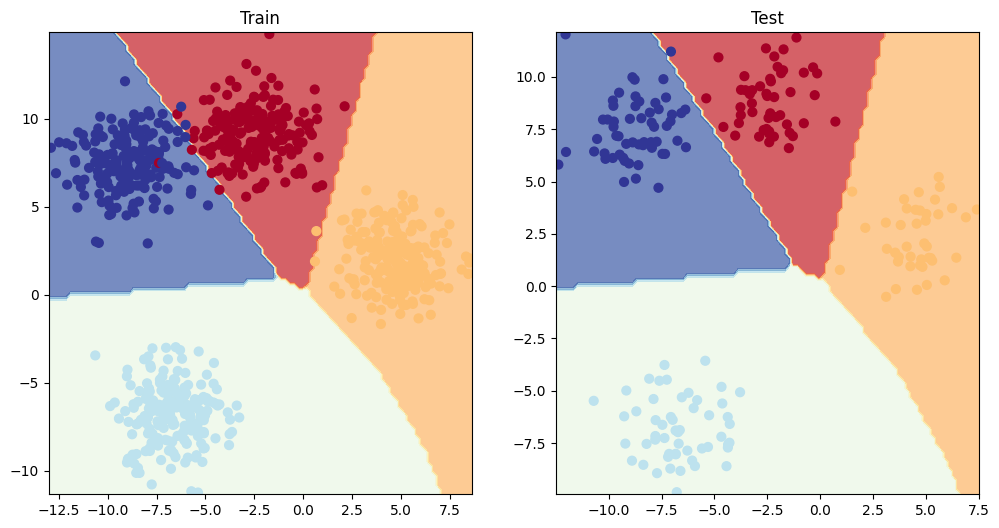

In [ ]:
# Visualization
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_4,X_blob_test, y_blob_test)

### 9. A few more classification metrics (to evaluate our classification model)

* Accuracy - out of 100 samples, how many does our model predict right?
* Precision
* Recall
* F1-score
* Confusion matrix
* Classification report

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.1 MB/s eta 0:00:00


In [ ]:
from torchmetrics import Accuracy

# Setup metric
torchmetrics_acc = Accuracy(task="multiclass", num_classes=4).to(device)

# Calculate accuracy
torchmetrics_acc(y_preds, y_blob_test)

tensor(0.9950)